## Decoding image identity from VISp with CEBRA

This notebook adapts the official CEBRA Allen workflow (for figure 3b) to the Allen Visual Behavior Neuropixels dataset.  
We use CEBRA to try to answer: **Can CEBRA learn a low-dimensional latent representation of VISp spiking activity that accurately predicts which image was presented?**

### Setup

We use the Allen Visual Behavior Neuropixels dataset.  
Here are the imports we used. They are similar to those used in our replication step. We then build the neural matrix ourselves from repeated image presentations.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from allensdk.brain_observatory.behavior.behavior_project_cache import (
    VisualBehaviorNeuropixelsProjectCache
)

from cebra import CEBRA

DEVICE = "cpu"
print("Using device:", DEVICE)

cache_dir = "./allen_vbn_cache"
os.makedirs(cache_dir, exist_ok=True)

cache = VisualBehaviorNeuropixelsProjectCache.from_s3_cache(cache_dir=cache_dir)

Using device: cpu


### Preapring the data

We restruct the Allen Visual Behavior Neuropixels data to strictly VISp (primary visual cortex) data. We choose a single session based on how many VISp data is contained within each one. Our candidate sessions IDs are taken from a manual data inspection.

In [2]:
sessions = cache.get_ecephys_session_table()
units = cache.get_unit_table()

In [3]:
candidate_sessions = [1108334384, 1087723305, 1043752325]

visp_counts = (units[units["structure_acronym"] == "VISp"].groupby("ecephys_session_id").size().rename("n_visp_units"))

candidate_summary = pd.DataFrame(index=candidate_sessions)
candidate_summary["# Visp Data"] = visp_counts.reindex(candidate_sessions).fillna(0).astype(int)

display(candidate_summary)

session_id = candidate_summary["# Visp Data"].idxmax()
print("Selected session:", session_id)

session = cache.get_ecephys_session(ecephys_session_id=session_id)

,# Visp Data
1108334384,220
1087723305,189
1043752325,231


Selected session: 1043752325


/home/adl007/.local/lib/python3.11/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


,warped
image_name,
im036_r,"[[70, 71, 67, 63, 64, 69, 73, 73, 71, 70, 73, ..."
im012_r,"[[25, 27, 21, 14, 15, 23, 29, 28, 22, 18, 20, ..."
im044_r,"[[20, 23, 16, 9, 9, 18, 24, 23, 16, 12, 14, 20..."
im047_r,"[[63, 65, 62, 58, 58, 63, 67, 67, 65, 64, 65, ..."
im083_r,"[[6, 9, 2, 0, 0, 0, 7, 5, 0, 0, 0, 2, 7, 6, 2,..."


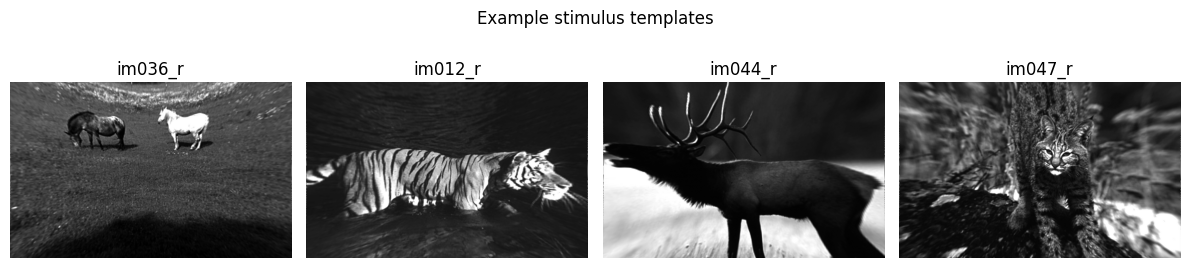

In [4]:
templates = session.stimulus_templates.copy()

# Show table without the unwarped image arrays
display(templates.drop(columns=["unwarped"], errors="ignore").head())

if "warped" in templates.columns:
    image_names = templates.index[:4]
    fig, axes = plt.subplots(1, len(image_names), figsize=(12, 3))
    
    for ax, img_name in zip(axes, image_names):
        ax.imshow(templates.loc[img_name, "warped"], cmap="gray")
        ax.set_title(str(img_name))
        ax.axis("off")
    
    plt.suptitle("Example stimulus templates")
    plt.tight_layout()
    plt.show()

### Build a repeated-image dataset

To stay close to the demo’s visual-content decoding setup, we use repeated image presentations.
We keep non-omitted image flashes and, when available, prefer passive/non-change presentations to reduce motor and decision-related contamination.

In [5]:
stimulus_presentations = session.stimulus_presentations.copy()
stim = stimulus_presentations.copy()

stim = stim.dropna(subset=["image_name", "start_time"])

if "omitted" in stim.columns:
    stim = stim[~stim["omitted"]]

if "is_change" in stim.columns:
    stim = stim[~stim["is_change"]]

stim = stim[stim["image_name"].astype(str).str.startswith("im")]

print("Remaining presentations:", len(stim))
display(stim.head())
display(stim["image_name"].value_counts())

Remaining presentations: 8946


,stimulus_block,image_name,duration,start_time,end_time,start_frame,end_frame,is_change,is_image_novel,omitted,...,orientation,position_x,rewarded,stimulus_index,contrast,is_sham_change,position_y,spatial_frequency,color,active
stimulus_presentations_id,,,,,,,,,,,,,,,,,,,,,
0,0,im036_r,0.250211,26.274263,26.524474,60,75,False,False,False,...,NaN,NaN,False,-99,NaN,False,NaN,NaN,NaN,True
1,0,im036_r,0.250211,27.024897,27.275108,105,120,False,False,False,...,NaN,NaN,False,-99,NaN,False,NaN,NaN,NaN,True
2,0,im036_r,0.250209,27.775526,28.025734,150,165,False,False,False,...,NaN,NaN,False,-99,NaN,False,NaN,NaN,NaN,True
3,0,im036_r,0.250216,28.526159,28.776376,195,210,False,False,False,...,NaN,NaN,False,-99,NaN,False,NaN,NaN,NaN,True
4,0,im036_r,0.266881,29.276808,29.543689,240,256,False,False,False,...,NaN,NaN,False,-99,NaN,False,NaN,NaN,NaN,True


im083_r    1464
im078_r    1330
im115_r    1238
im044_r    1236
im111_r    1092
im012_r     950
im036_r     838
im047_r     798
Name: image_name, dtype: int64

In [7]:
# Keep the 8 most common image identities and balance the dataset
topImages = stim["image_name"].value_counts().index[:8]
stim = stim[stim["image_name"].isin(topImages)].copy()

minCount = stim["image_name"].value_counts().min()

stimBalanced = (
    stim.groupby("image_name", group_keys=False)
    .sample(n=minCount, random_state=0)
    .sort_values("start_time")
    .reset_index(drop=True)
)

print("Balanced presentations per image:", minCount)
print("Total balanced presentations:", len(stimBalanced))
display(stimBalanced["image_name"].value_counts())

Balanced presentations per image: 798
Total balanced presentations: 6384


im036_r    798
im078_r    798
im083_r    798
im047_r    798
im012_r    798
im111_r    798
im115_r    798
im044_r    798
Name: image_name, dtype: int64

### Construct presentation-aligned neural features

We now align VISp spike times to image onset and convert them into a presentation × neuron × time-bin tensor.  
This is the closest analogue, from our starting dataset, to the “1 frame window” setup used in the official Allen CEBRA demo.

In [8]:
session_units = session.get_units().copy()

if "structure_acronym" not in session_units.columns:
    session_units = session_units.join(units[["structure_acronym"]], how="left")

if "quality" in session_units.columns:
    good_mask = session_units["quality"].astype(str).str.lower().eq("good")
else:
    good_mask = (
        (session_units.get("isi_violations", pd.Series(np.inf, index=session_units.index)) < 0.5) &
        (session_units.get("amplitude_cutoff", pd.Series(np.inf, index=session_units.index)) < 0.1) &
        (session_units.get("presence_ratio", pd.Series(0.0, index=session_units.index)) > 0.9)
    )

visp_units = session_units[
    good_mask &
    (session_units["structure_acronym"] == "VISp")
].copy()

print("Number of VISp units:", len(visp_units))
display(visp_units.head())

Number of VISp units: 194


,PT_ratio,amplitude,amplitude_cutoff,cluster_id,cumulative_drift,d_prime,firing_rate,isi_violations,isolation_distance,l_ratio,...,quality,recovery_slope,repolarization_slope,silhouette_score,snr,spread,velocity_above,velocity_below,waveform_duration,structure_acronym
id,,,,,,,,,,,,,,,,,,,,,
1163291401,0.303828,211.826940,0.000517,192,113.30,3.914024,1.296711,0.109704,40.863032,0.018399,...,good,-0.041675,0.697858,-0.086876,3.781320,60.0,0.824121,0.343384,0.686767,VISp
1163291395,0.654601,84.808718,0.010655,186,363.72,2.681995,4.713692,0.089666,57.763597,0.008951,...,good,-0.045590,0.185603,-0.001321,1.555594,60.0,0.686767,-0.549414,0.782915,VISp
1163291577,0.712732,55.838835,0.080098,370,325.10,2.922173,10.830497,0.137451,1049.560190,0.022023,...,good,-0.022584,0.139870,0.063934,1.538271,90.0,0.686767,-0.147164,0.549414,VISp
1163291440,0.489530,70.714410,0.179331,236,358.65,2.486814,0.967070,0.512822,28.609872,0.044606,...,good,-0.029011,0.220278,0.027560,1.138355,90.0,1.579564,0.549414,0.604355,VISp
1163291667,0.481047,96.063923,0.008647,458,289.50,2.529849,1.302223,0.087035,31.797698,0.016904,...,good,-0.022546,0.154318,-0.019438,1.017090,80.0,0.902608,-1.030151,0.659296,VISp


In [13]:
# One-image windows
bin_size = 0.025
window_start = 0.0
window_end = 0.25

bins = np.arange(window_start, window_end + bin_size, bin_size)
bin_centers = bins[:-1] + bin_size / 2

spike_times = session.spike_times
unit_ids = visp_units.index.to_numpy()
presentation_times = stimBalanced["start_time"].to_numpy()
presentation_labels = stimBalanced["image_name"].to_numpy()

n_presentations = len(presentation_times)
n_units = len(unit_ids)
n_bins = len(bin_centers)

print(f"Building tensor: {n_presentations} presentations x {n_units} units x {n_bins} bins")

firing_rates = np.zeros((n_presentations, n_units, n_bins), dtype=np.float32)

for i, t0 in enumerate(presentation_times):
    for j, uid in enumerate(unit_ids):
        spikes = spike_times[uid]
        rel_spikes = spikes - t0
        counts, _ = np.histogram(rel_spikes, bins=bins)
        firing_rates[i, j, :] = counts.astype(np.float32) / bin_size

print("firing_rates shape:", firing_rates.shape)

Building tensor: 6384 presentations x 194 units x 10 bins
firing_rates shape: (6384, 194, 10)


### Visualize the neural data

Before using CEBRA, we wanted to inspect the data. Here are some basic plots of the dataset we are using to train CEBRA

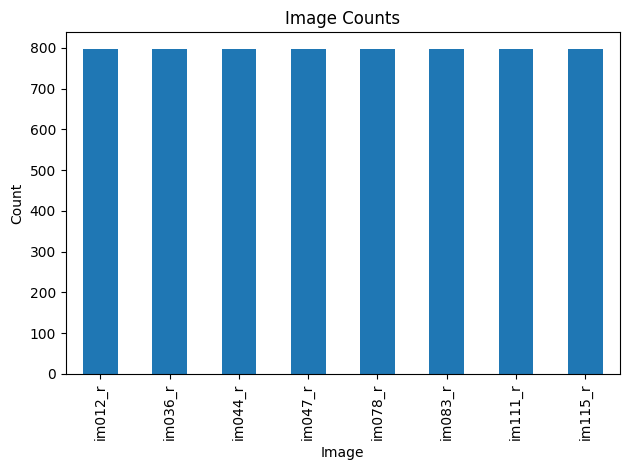

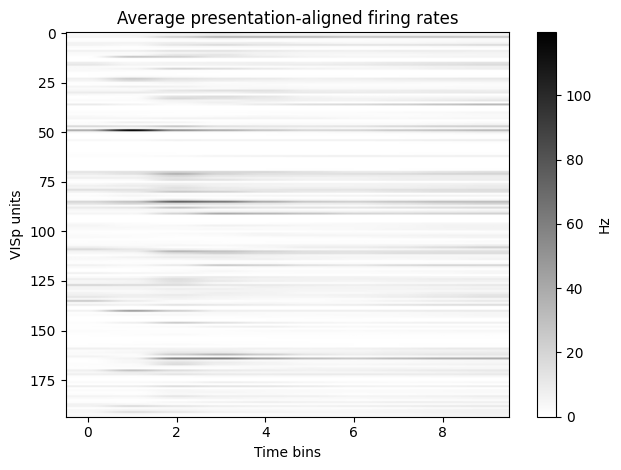

In [15]:
plt.figure()
stimBalanced["image_name"].value_counts().sort_index().plot(kind="bar")
plt.title("Image Counts")
plt.xlabel("Image")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

mean_over_presentations = firing_rates.mean(axis=0)

plt.figure()
plt.imshow(mean_over_presentations, aspect="auto", cmap="gray_r")
plt.xlabel("Time bins")
plt.ylabel("VISp units")
plt.title("Average presentation-aligned firing rates")
plt.colorbar(label="Hz")
plt.tight_layout()
plt.show()

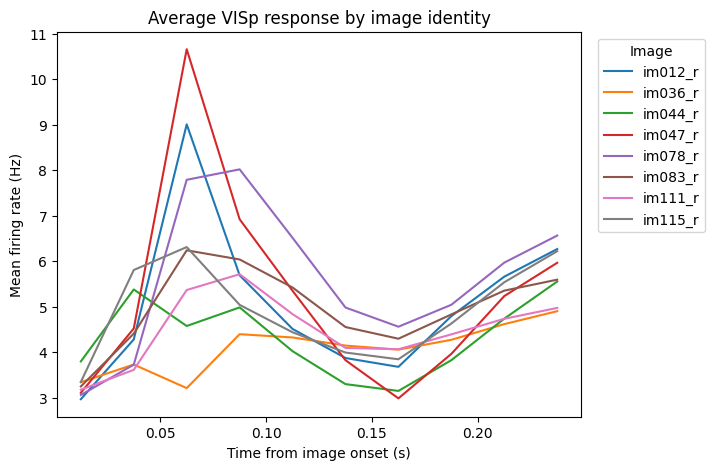

In [20]:
mean_by_image = {}
for img in sorted(stimBalanced["image_name"].unique()):
    mean_by_image[img] = firing_rates[presentation_labels == img].mean(axis=(0, 1))

fig, ax = plt.subplots(figsize=(8, 5))

for img, trace in mean_by_image.items():
    ax.plot(bin_centers, trace, label=img)

ax.set_xlabel("Time from image onset (s)")
ax.set_ylabel("Mean firing rate (Hz)")
ax.set_title("Average VISp response by image identity")

ax.legend(title="Image", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(right=0.78)

plt.show()

### Prepare the CEBRA inputs

The sklearn API expects a 2D sample × feature matrix.  
To use the sklearn-like CEBRA interface, presentation-level time bins are flattened into individual samples while preserving both within-presentation time and image class labels.

In [21]:
# maps image names to integers for CEBRA
label_encoder = LabelEncoder()
y_presentations = label_encoder.fit_transform(presentation_labels)
class_names = label_encoder.classes_

print("Classes:", list(class_names))

Classes: ['im012_r', 'im036_r', 'im044_r', 'im047_r', 'im078_r', 'im083_r', 'im111_r', 'im115_r']


In [22]:
# converts the data to the corrected format
def make_bin_level_dataset(X_presentations, y_presentations, times):
    n_presentations, n_units, n_bins = X_presentations.shape
    X_bins = X_presentations.transpose(0, 2, 1).reshape(n_presentations * n_bins, n_units)
    y_bins = np.repeat(y_presentations, n_bins)
    time_idx = np.tile(times, n_presentations).reshape(-1, 1)
    return X_bins, time_idx, y_bins

# add
def average_bins_back_to_presentations(Z_bins, n_presentations, n_bins):
    return Z_bins.reshape(n_presentations, n_bins, -1).mean(axis=1)

# add
def choose_best_k(X_train, y_train, X_val, y_val, k_grid=(1, 3, 5, 7, 9, 15)):
    best_k = None
    best_score = -np.inf
    for k in k_grid:
        clf = KNeighborsClassifier(n_neighbors=k, metric="cosine")
        clf.fit(X_train, y_train)
        pred = clf.predict(X_val)
        score = balanced_accuracy_score(y_val, pred)
        if score > best_score:
            best_score = score
            best_k = k
    return best_k, best_score

In [23]:
X_presentations = firing_rates.copy()
y = y_presentations.copy()

outer = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=0)
trainval_idx, test_idx = next(outer.split(np.zeros(len(y)), y))

X_trainval = X_presentations[trainval_idx]
X_test = X_presentations[test_idx]
y_trainval = y[trainval_idx]
y_test = y[test_idx]

inner = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
train_idx_rel, val_idx_rel = next(inner.split(np.zeros(len(y_trainval)), y_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

print("Train CEBRA with presentations:", len(y_train))
print("Validated presentations:", len(y_val))
print("Test presentations:", len(y_test))

Train CEBRA with presentations: 3830
Validated presentations: 1277
Test presentations: 1277


In [24]:
# Each presentation is put into time-bin samples
X_train_bins, train_time_idx, y_train_bins = make_bin_level_dataset(X_train, y_train, bin_centers)
X_val_bins, val_time_idx, y_val_bins = make_bin_level_dataset(X_val, y_val, bin_centers)
X_test_bins, test_time_idx, y_test_bins = make_bin_level_dataset(X_test, y_test, bin_centers)

scaler = StandardScaler(with_mean=True, with_std=True)
X_train_bins_z = scaler.fit_transform(X_train_bins)
X_val_bins_z = scaler.transform(X_val_bins)
X_test_bins_z = scaler.transform(X_test_bins)

print("Bin-level train shape:", X_train_bins_z.shape)

Bin-level train shape: (38300, 194)


### Baseline decoders

We similarly evaluate whether the learned representation using CEBRA actually helps decoding.  
Before using CEBRA, we compare against simple baselines built from presentation-level neural features.

In [25]:
# Baseline: mean over bins + kNN (simplest decoder)
raw_train = X_train.mean(axis=2)
raw_val = X_val.mean(axis=2)
raw_test = X_test.mean(axis=2)

raw_scaler = StandardScaler()
raw_train_z = raw_scaler.fit_transform(raw_train)
raw_val_z = raw_scaler.transform(raw_val)
raw_test_z = raw_scaler.transform(raw_test)

best_k_raw, _ = choose_best_k(raw_train_z, y_train, raw_val_z, y_val)
clf_raw = KNeighborsClassifier(n_neighbors=best_k_raw, metric="cosine")
clf_raw.fit(raw_train_z, y_train)
pred_raw = clf_raw.predict(raw_test_z)

# Baseline 2: PCA + kNN
pca = PCA(n_components=min(8, raw_train_z.shape[1]))
pca_train = pca.fit_transform(raw_train_z)
pca_val = pca.transform(raw_val_z)
pca_test = pca.transform(raw_test_z)

best_k_pca, _ = choose_best_k(pca_train, y_train, pca_val, y_val)
clf_pca = KNeighborsClassifier(n_neighbors=best_k_pca, metric="cosine")
clf_pca.fit(pca_train, y_train)
pred_pca = clf_pca.predict(pca_test)

print("Raw accuracy:", accuracy_score(y_test, pred_raw))
print("PCA accuracy:", accuracy_score(y_test, pred_pca))

Raw accuracy: 0.9350039154267815
PCA accuracy: 0.9154267815191856


### Train the CEBRA model

Uses Neuropixels in a one-image window identifying visual-content labels to decode stimulus identity. Uses 800 iterations for a balance between accuracy (training the model enough) and time (spent training). Fewer iterations result in markedly worse performance.

In [26]:
cebra_model = CEBRA(
    model_architecture="offset10-model",
    batch_size=256,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=800,
    distance="cosine",
    conditional="time_delta",
    time_offsets=3,
    device=DEVICE,
    verbose=True,
)

In [27]:
cebra_model.fit(X_train_bins_z, train_time_idx, y_train_bins)

Z_train_bins = cebra_model.transform(X_train_bins_z)
Z_val_bins = cebra_model.transform(X_val_bins_z)
Z_test_bins = cebra_model.transform(X_test_bins_z)

n_train_presentations, _, n_bins = X_train.shape
n_val_presentations, _, _ = X_val.shape
n_test_presentations, _, _ = X_test.shape

Z_train = average_bins_back_to_presentations(Z_train_bins, n_train_presentations, n_bins)
Z_val = average_bins_back_to_presentations(Z_val_bins, n_val_presentations, n_bins)
Z_test = average_bins_back_to_presentations(Z_test_bins, n_test_presentations, n_bins)

pos: -0.9051 neg:  5.6730 total:  4.7680 temperature:  1.0000: 100%|██████████| 800/800 [02:07<00:00,  6.27it/s]


### Results

Using our accuracy_score function, we check to see how good CEBRA did against the baseline

In [28]:
best_k_cebra, _ = choose_best_k(Z_train, y_train, Z_val, y_val)
clf_cebra = KNeighborsClassifier(n_neighbors=best_k_cebra, metric="cosine")
clf_cebra.fit(Z_train, y_train)
pred_cebra = clf_cebra.predict(Z_test)

results_df = pd.DataFrame([
    {
        "model": "Raw mean + kNN",
        "accuracy": accuracy_score(y_test, pred_raw),
    },
    {
        "model": "PCA + kNN",
        "accuracy": accuracy_score(y_test, pred_pca),
    },
    {
        "model": "CEBRA + kNN",
        "accuracy": accuracy_score(y_test, pred_cebra),
    },
])

display(results_df)

,model,accuracy
0,Raw mean + kNN,0.935004
1,PCA + kNN,0.915427
2,CEBRA + kNN,0.972592


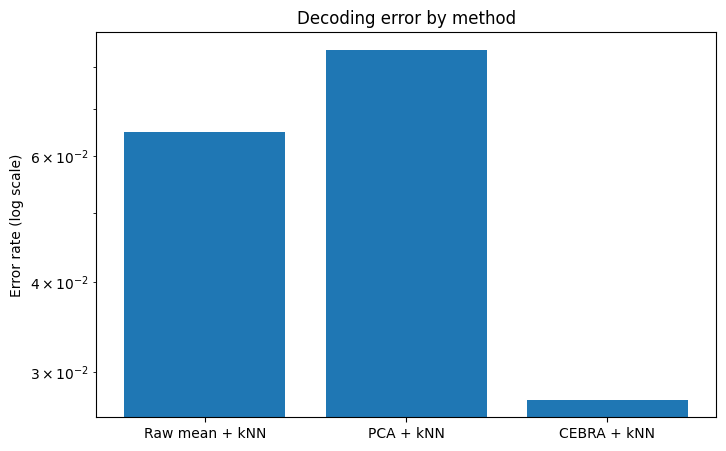

In [29]:
# error rate of each of the models. Originally did accuracy but the difference didn't seem as obvious and this type of figure gives more information
models = results_df["model"].tolist()
x = np.arange(len(models))

acc = results_df["accuracy"].to_numpy()
error = 1 - acc
eps = 1e-6

plt.figure(figsize=(8, 5))
plt.bar(x, error + eps)

plt.xticks(x, models)
plt.yscale("log")
plt.ylabel("Error rate (log scale)")
plt.title("Decoding error by method")
plt.show()

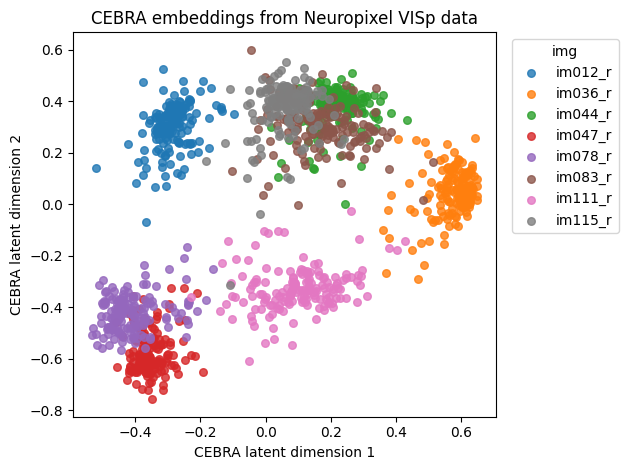

In [30]:
plt.figure()

for cls_idx, cls_name in enumerate(class_names):
    mask = y_test == cls_idx
    plt.scatter(
        Z_test[mask, 0],
        Z_test[mask, 1],
        s=30,
        alpha=0.8,
        label=str(cls_name)
    )

plt.xlabel("CEBRA latent dimension 1")
plt.ylabel("CEBRA latent dimension 2")
plt.title("CEBRA embeddings from Neuropixel VISp data")
plt.legend(title="img", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

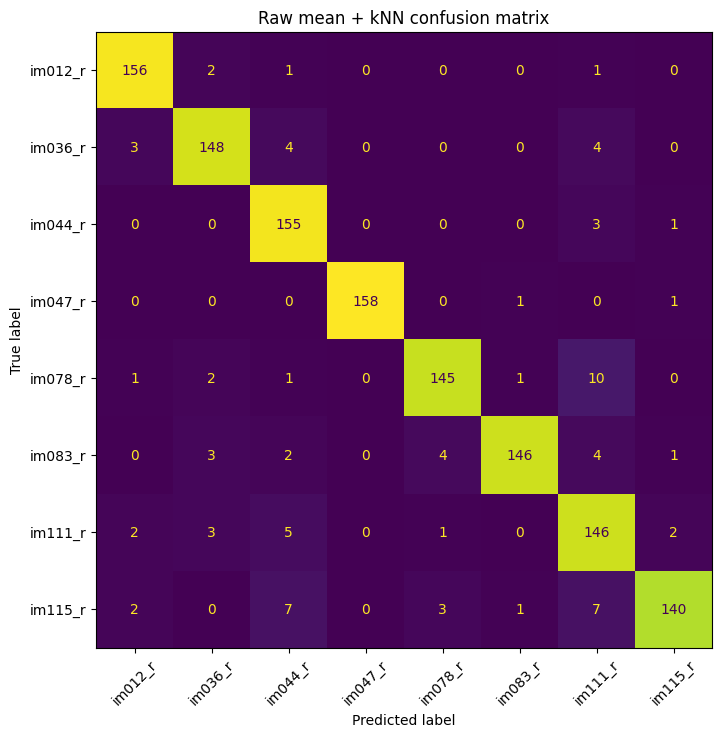

In [31]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, pred_raw),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Raw mean + kNN confusion matrix")
plt.show()

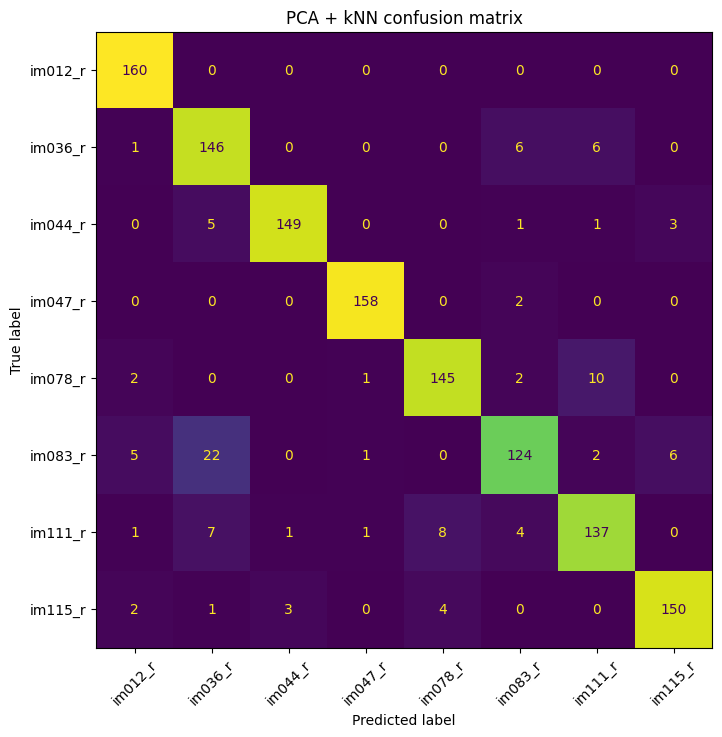

In [32]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, pred_pca),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("PCA + kNN confusion matrix")
plt.show()

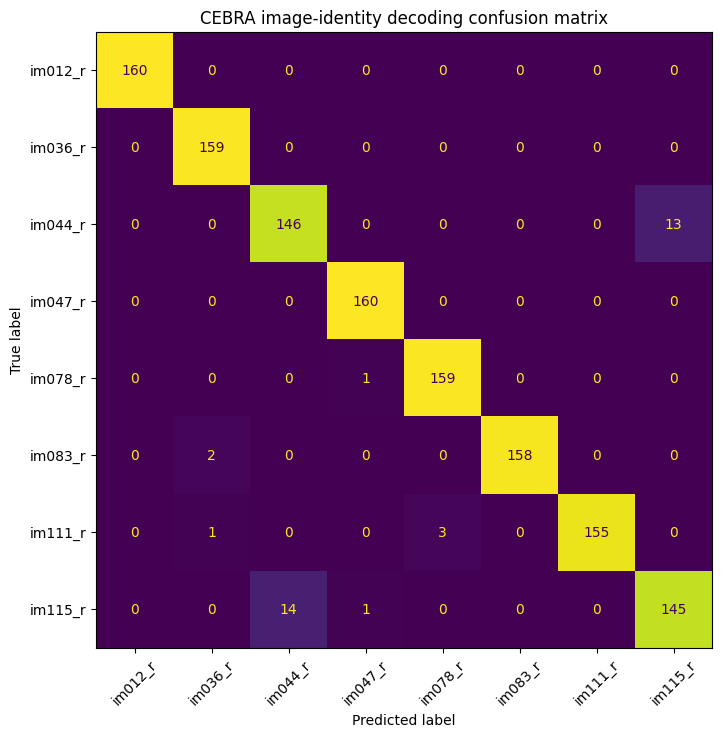

In [33]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, pred_cebra),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("CEBRA image-identity decoding confusion matrix")
plt.show()

,model,mean_pairwise_center_distance
0,PCA,1.692143
1,CEBRA,0.663452


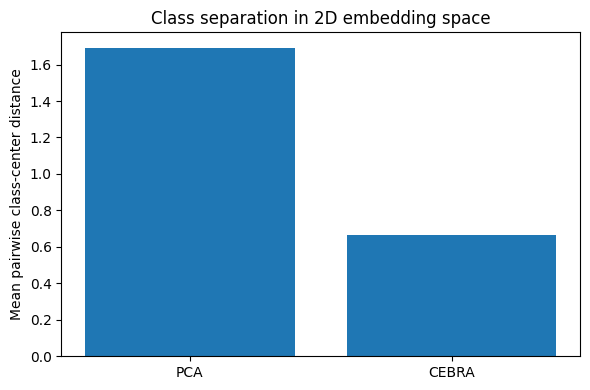

In [34]:
def mean_pairwise_class_distance(X, y):
    centers = []
    for cls in np.unique(y):
        centers.append(X[y == cls].mean(axis=0))
    centers = np.array(centers)

    dists = []
    for i in range(len(centers)):
        for j in range(i + 1, len(centers)):
            dists.append(np.linalg.norm(centers[i] - centers[j]))
    return np.mean(dists)

pca_sep = mean_pairwise_class_distance(pca_test[:, :2], y_test)
cebra_sep = mean_pairwise_class_distance(Z_test[:, :2], y_test)

sep_df = pd.DataFrame([
    {"model": "PCA", "mean_pairwise_center_distance": pca_sep},
    {"model": "CEBRA", "mean_pairwise_center_distance": cebra_sep},
])

display(sep_df)

plt.figure(figsize=(6, 4))
plt.bar(sep_df["model"], sep_df["mean_pairwise_center_distance"])
plt.ylabel("Mean pairwise class-center distance")
plt.title("Class separation in 2D embedding space")
plt.tight_layout()
plt.show()